# Heart Disease Data Analysis

## Introduction

Heart disease is a common health condition that affects millions of people around the world. The objective of this project is to analyze a heart disease dataset, explore the relationships between medical features and heart disease, and build a classification model to predict whether a patient has heart disease. The performance of the model is then evaluated using standard classification metrics.

## Dataset Description

The Heart Disease Cleveland dataset contains medical information collected from patients to help identify the presence of heart disease. The dataset includes demographic information and clinical measurements such as age, gender, chest pain type, blood pressure, cholesterol level, maximum heart rate, and other medical indicators. The target variable indicates whether a patient has heart disease or not, making it suitable for binary classification tasks.

### Why this Dataset?

This dataset was selected because heart disease is one of the most common health conditions worldwide. It provides a good opportunity to explore medical data, discover meaningful patterns, and build a simple classification model to predict heart disease.

## Problem Definition

The goal of this project is to predict whether a patient has heart disease based on medical features such as age, chest pain type, cholesterol, blood pressure, and maximum heart rate.

This is a classification problem because the target variable contains two categories:

- 0 = No heart disease
- 1 = Heart disease


In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [4]:
df = pd.read_csv("heart_cleveland_upload.csv")

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


- age: Patient's age in years.

- sex: Patient's gender (0 = Female, 1 = Male).

- cp: Type of chest pain experienced by the patient.

- trestbps: Resting blood pressure (mm Hg).

- chol: Serum cholesterol level (mg/dL).

- fbs: Fasting blood sugar (1 = >120 mg/dL, 0 = <=120 mg/dL).

- restecg: Resting electrocardiogram (ECG) results.

- thalach: Maximum heart rate achieved.

- exang: Exercise-induced angina (0 = No, 1 = Yes).

- oldpeak: ST depression induced by exercise.

- slope: Slope of the peak exercise ST segment.

- ca: Number of major blood vessels detected.

- thal: Thalassemia test result.

- condition: Target variable (0 = No heart disease, 1 = Heart disease).

In [8]:
df.shape

(297, 14)

In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
df.isnull()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,False,False,False,False,False,False,False,False,False,False,False,False,False,False
293,False,False,False,False,False,False,False,False,False,False,False,False,False,False
294,False,False,False,False,False,False,False,False,False,False,False,False,False,False
295,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Data Cleaning Summary

- No missing values were found.
- No duplicate rows were found.
- All columns have appropriate numeric data types.
- The dataset was ready for analysis without major preprocessing.

In [13]:
df['condition'].value_counts()

,count
condition,
0,160
1,137


In [14]:
df['condition'].value_counts(normalize=True) * 100

,proportion
condition,
0,53.872054
1,46.127946


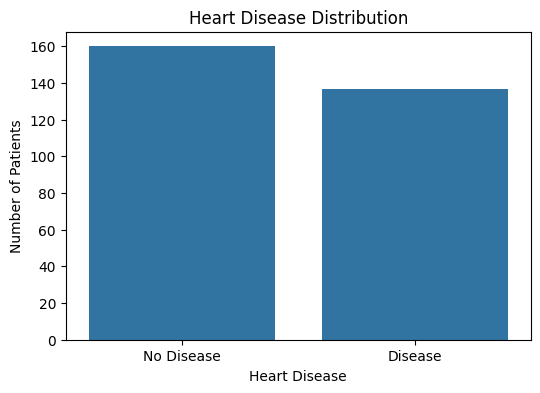

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='condition', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0,1],["No Disease","Disease"])

plt.show()

### Observation

The dataset contains both patients with heart disease and patients without heart disease. The two classes are relatively balanced, which makes accuracy a reasonable evaluation metric for the model.


In [16]:
df.corr()['condition'].sort_values(ascending=False)

,condition
condition,1.000000
thal,0.520516
ca,0.463189
oldpeak,0.424052
exang,0.421355
cp,0.408945
slope,0.333049
sex,0.278467
age,0.227075
restecg,0.166343


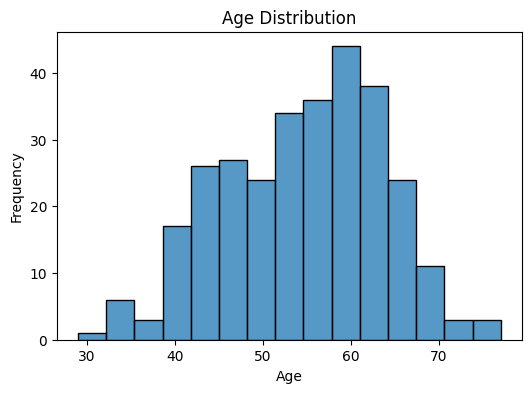

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Observation

- Most patients are between 50 and 65 years old, indicating that middle-aged and older adults make up the majority of the dataset.

- This suggests that age may be associated with heart disease.

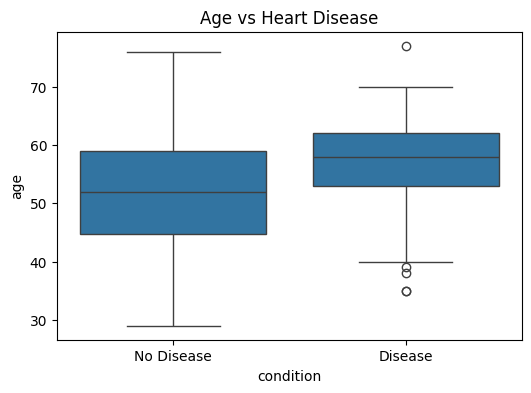

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='condition', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.xticks([0,1],["No Disease","Disease"])
plt.show()

### Observation

- Patients diagnosed with heart disease generally tend to be older than patients without heart disease, suggesting that age may be associated with the condition.
- A few outliers were observed in some numerical features, but they were retained because they may represent valid medical cases rather than data errors.

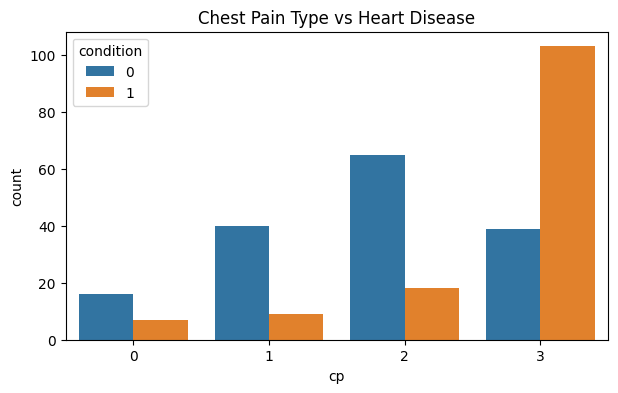

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(x='cp', hue='condition', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

### Observation

The distribution of chest pain types differs between healthy and affected patients, indicating that chest pain may be an important predictor of heart disease.

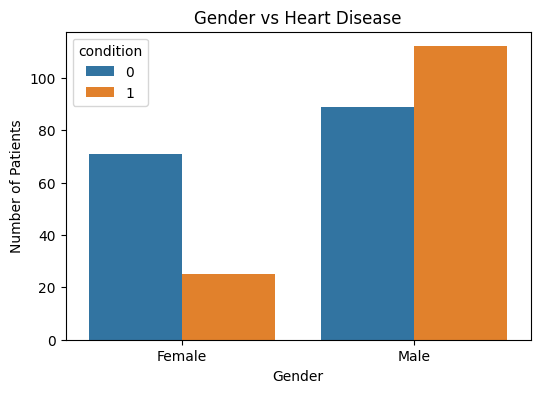

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', hue='condition', data=df)

plt.title("Gender vs Heart Disease")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks([0,1],["Female","Male"])

plt.show()

###Observation

Male patients appear to have a higher number of heart disease cases than female patients in this dataset, suggesting that gender may be associated with heart disease.

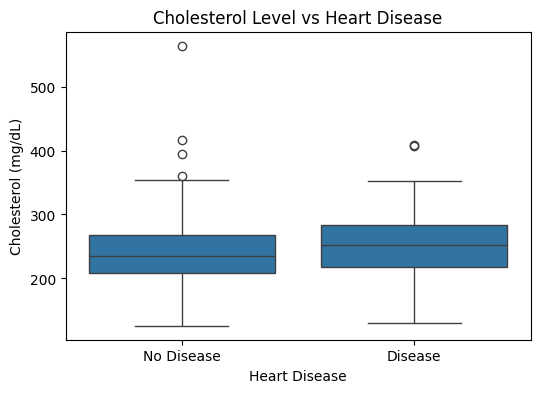

In [31]:
plt.figure(figsize=(6,4))

sns.boxplot(x='condition', y='chol', data=df)

plt.title("Cholesterol Level vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol (mg/dL)")
plt.xticks([0,1],["No Disease","Disease"])

plt.show()

### Observation

Patients with heart disease tend to have slightly higher cholesterol levels than patients without heart disease. However, there is considerable overlap between the two groups, suggesting that cholesterol alone is not a strong predictor of heart disease in this dataset. Several outliers are also present in both groups.

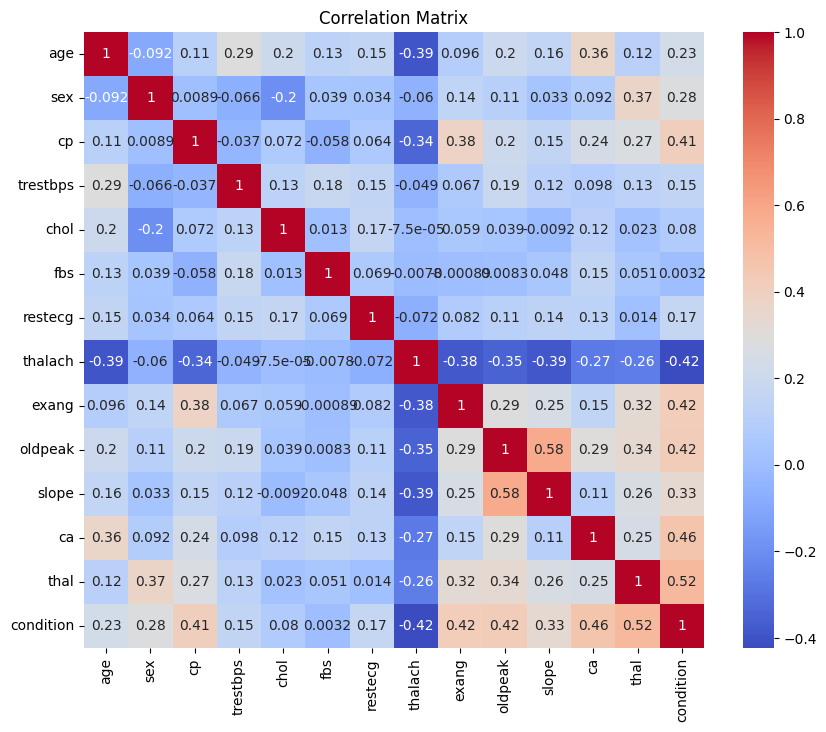

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Observation

Features such as thal, ca , oldpeak, cp, and thalach show stronger relationships with heart disease compared to the other variables.

In [21]:
X = df[["age" , "sex" , "cp" , "thalach" , "exang" , "oldpeak" , "thal"]]
y = df["condition"]

- The selected features were chosen based on their medical relevance and their correlation with the target variable. These features showed stronger relationships with heart disease and are commonly used as indicators for predicting heart disease.

# Insights Summary

- The dataset is relatively balanced, making it suitable for classification.
- Most patients are between 50 and 65 years old.
- Older patients are more likely to have heart disease.
- Chest pain type and maximum heart rate show noticeable relationships with heart disease.
- Cholesterol alone is not a strong predictor because there is considerable overlap between the two groups.
- Correlation analysis identified thal, ca, oldpeak, and cp as the most informative features.

### Modelling

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
model = LogisticRegression()
model.fit(X_train , y_train)

LogisticRegression()

In [25]:
y_pred = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test , y_pred)
print(accuracy)

0.7166666666666667


In [27]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[23  9]
 [ 8 20]]
              precision    recall  f1-score   support

           0       0.74      0.72      0.73        32
           1       0.69      0.71      0.70        28

    accuracy                           0.72        60
   macro avg       0.72      0.72      0.72        60
weighted avg       0.72      0.72      0.72        60



### Observation


The Logistic Regression model achieved an accuracy of 71.67% on the test dataset. This means that the model correctly classified approximately 72% of the patients. The classification report shows that the model performed reasonably well for both classes, with balanced precision, recall, and F1-scores. Overall, the model provides acceptable performance for a simple baseline classification model.

In [35]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)


print("Decision Tree Accuracy:", accuracy_tree)


print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.6666666666666666
[[20 12]
 [ 8 20]]
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        32
           1       0.62      0.71      0.67        28

    accuracy                           0.67        60
   macro avg       0.67      0.67      0.67        60
weighted avg       0.67      0.67      0.67        60



### Observation

The Decision Tree model achieved an accuracy of 66.67%, which is lower than the Logistic Regression model. This indicates that the Decision Tree was less effective in predicting heart disease for this dataset.

## Limitations

- The dataset contains only 297 records.
- The model was trained using a limited number of features.
- The results may not generalize to larger populations.
## Future Work

- Test additional machine learning models.
- Tune model hyperparameters.
- Use larger datasets to improve prediction performance.

## Final Conclusion

In this project, two classification models were evaluated: Logistic Regression and Decision Tree. Logistic Regression achieved the highest accuracy (71.67%), while Decision Tree achieved 66.67%. Based on these results, Logistic Regression was selected as the final model because it provided better overall performance for predicting heart disease in this dataset.